# Survival probability vs propensity score 

**This notebook plots calibrated 6-month survival probability against propensity score for the mRCC cohort (ipi/nivo or TKI).**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iptw_survival import OverlapWeightSurvivalEstimator

from scipy import stats

## Import data 

### Import calibrated survival probabilities 

In [2]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [3]:
surv_pred_df.head(3)

,PatientID,psurv_180_calibrated
0,F42ACFD609CE6,0.868056
1,F2A697A9BC9E5,0.554913
2,F1D409FF1E1DF,0.959998


In [4]:
surv_pred_df.shape

(4193, 2)

### Import treatment assignment

In [5]:
treatment_df = pd.read_csv('../outputs/ioio_tki_index.csv')

In [6]:
treatment_df.shape

(4831, 3)

In [7]:
treatment_df.head(3)

,PatientID,LineName,StartDate
0,F50AB9E183B8B,ioio,2020-04-02
1,F0DAF71F2552A,ioio,2019-04-25
2,F7F5EFF0FA2B5,ioio,2019-11-21


### Import features

In [8]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/ioio_tki_features.csv', dtype = dtype_map)

In [9]:
features_df.shape

(4366, 161)

### Import RMST pseudo-observations

In [10]:
pseudo_obs_df = pd.read_csv('../outputs/pseudo_obs_rmst.csv')

In [11]:
pseudo_obs_df.shape

(4193, 3)

In [12]:
pseudo_obs_df.head(3)

,PatientID,rmst_pseudo_2y,rmst_pseudo_3y
0,F42ACFD609CE6,629.477701,836.843506
1,F2A697A9BC9E5,744.854641,949.129158
2,F1D409FF1E1DF,744.854641,1016.112684


### Merge dataframes

In [13]:
df = pd.merge(features_df, surv_pred_df, on = 'PatientID', how = 'left')

In [14]:
df.shape

(4366, 162)

In [15]:
df = pd.merge(df, pseudo_obs_df, on = 'PatientID', how = 'left')

In [16]:
df.shape

(4366, 164)

In [17]:
df = pd.merge(df, treatment_df, on = 'PatientID', how = 'left')

In [18]:
df.shape

(4366, 166)

In [19]:
df = df.query('met_diagnosis_year <= 2020')

In [20]:
df.shape

(4193, 166)

## Calculating overlap weights

In [21]:
df['treatment'] = np.where(df['LineName'] == 'ioio', 1, 0)

In [22]:
df.treatment.value_counts()

treatment
0    3421
1     772
Name: count, dtype: int64

In [23]:
estimator = OverlapWeightSurvivalEstimator(normalize = None)

In [24]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['GroupStage'],
              cont_var = ['days_diagnosis_to_met', 'age', 'ecog_index', 'weight_index', 'percent_change_weight', 'albumin', 'creatinine', 'calcium', 'neutrophil', 'platelet', 'hemoglobin', 'van_walraven_score'],
              binary_var = ['Nephrectomy_mod', 'ecog_index_na', 'SmokingStatus', 'commercial', 'medicaid', 'days_to_treatment_before_1y'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [25]:
overlap_df = estimator.transform()

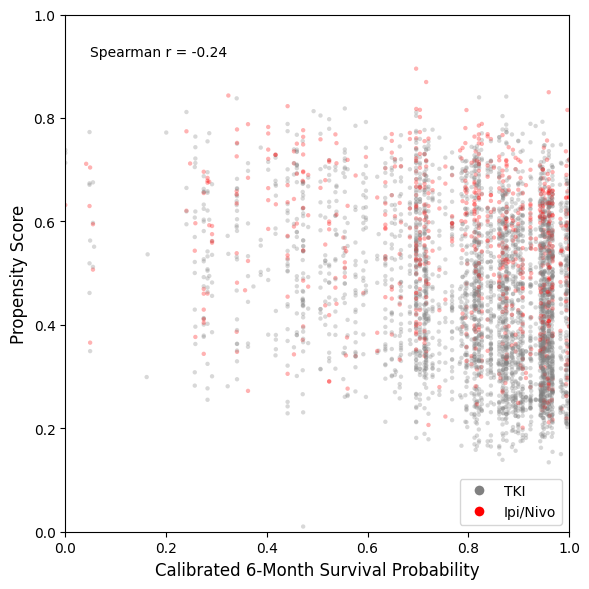

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))

colors = overlap_df['treatment'].map({0: 'gray', 1: 'red'})

ax.scatter(
    overlap_df['psurv_180_calibrated'],
    overlap_df['propensity_score'],
    c=colors,
    alpha=0.3,
    s=10,
    linewidths=0
)

# Correlation
r, _= stats.spearmanr(
    overlap_df['psurv_180_calibrated'],
    overlap_df['propensity_score']
)

ax.annotate(
    f'Spearman r = {r:.2f}',
    xy=(0.05, 0.92),
    xycoords='axes fraction',
    fontsize=10
)

ax.set_xlabel('Calibrated 6-Month Survival Probability', fontsize=12)
ax.set_ylabel('Propensity Score', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='TKI'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Ipi/Nivo')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()